# Customer Churn Prediction using Artificial Neural Network (ANN)

## Project Objective

The goal of this project is to predict whether a customer is likely to leave a telecom company based on customer information such as tenure, contract type, monthly charges, internet service, and payment method.

## Problem Type

Binary Classification

Target Variable:
- Churn (Yes/No)

## Concepts Covered

- Artificial Neural Network (ANN)
- Weights and Biases
- Forward Propagation
- Backpropagation
- Gradient Descent
- Learning Rate
- Data Preprocessing
- Feature Scaling
- Model Evaluation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Dataset

In this step, we load the Telco Customer Churn dataset into a Pandas DataFrame.

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hp\Documents\Customer_Churn_Prediction\Customer_Churn_Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Step 2: Display First Five Rows

This helps us understand the structure of the dataset.

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3: Dataset Shape

Check the number of rows and columns.

Rows = Customers

Columns = Features

In [11]:
df.shape

(7043, 21)

# Step 4: Dataset Information

This helps identify:

- Data types
- Missing values
- Numerical columns
- Categorical columns

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Step 5: Column Names

Display all columns present in the dataset.

In [19]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Understanding Inputs and Outputs

Target Variable:

- Churn

Input Features:

- Gender
- Tenure
- Contract
- Internet Service
- Monthly Charges
- Payment Method
- and other customer attributes

The ANN will learn patterns from these features to predict churn.

In [22]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Step 6: Check Missing Values

Missing values must be handled before training the ANN.



In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Observation

No missing values were found in the dataset.

# Step 7: Exploratory Data Analysis (EDA)

Visualize churn distribution.

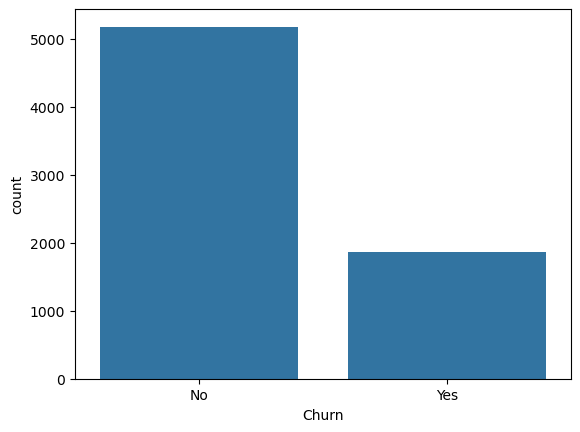

In [29]:
sns.countplot(x="Churn", data=df)
plt.show()

# Business Insight

This chart shows the number of customers who stayed and customers who left.

Understanding class distribution is important because imbalanced data can affect model performance.

# Step 8: Numerical Feature Analysis

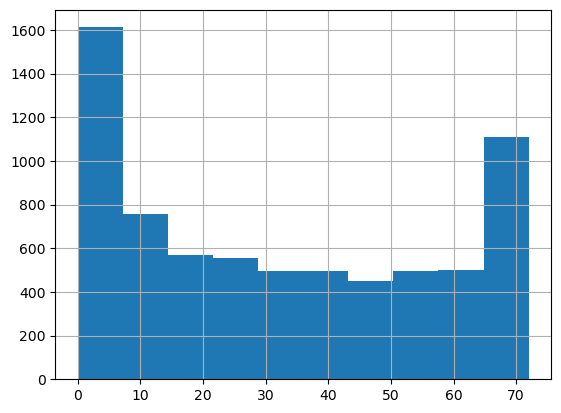

In [33]:
df['tenure'].hist()
plt.show()

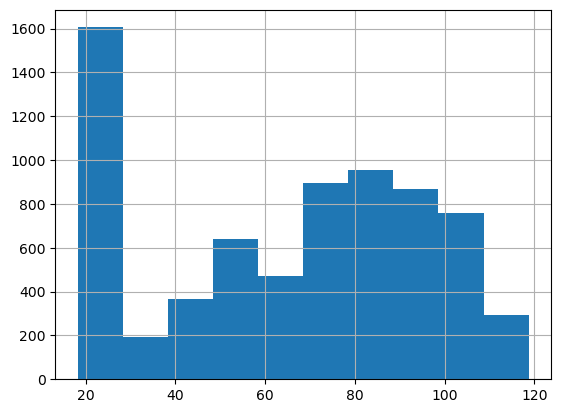

In [35]:
df['MonthlyCharges'].hist()
plt.show()

# Step 9: Outlier Analysis

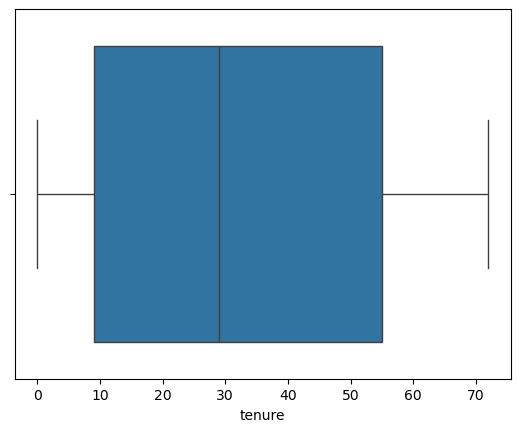

In [38]:
sns.boxplot(x=df['tenure'])
plt.show()

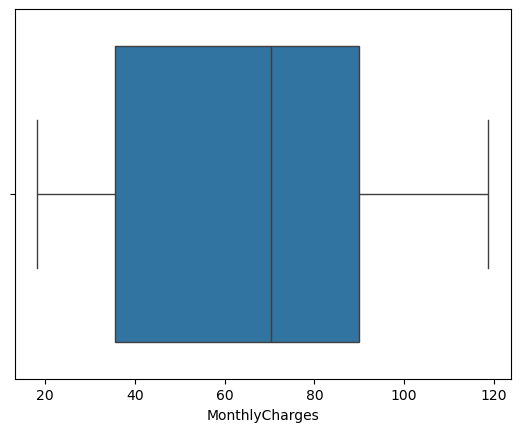

In [40]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

# Step 10: Feature Relationship Analysis

Analyze relationships between important features and customer churn.

## Contract Type vs Churn

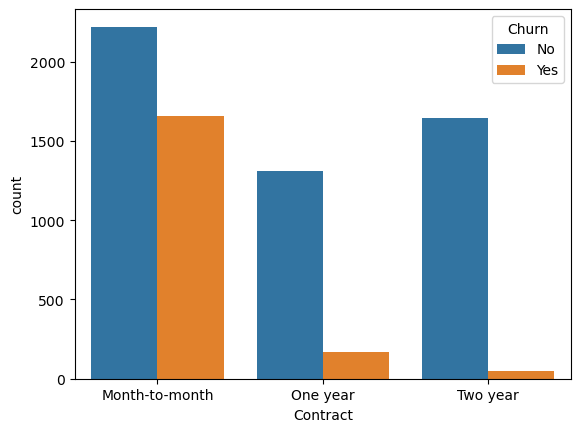

In [44]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

## Internet Service vs Churn

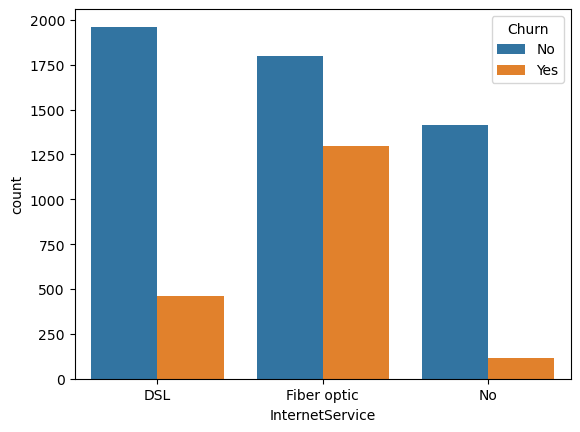

In [47]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

## Business Insight

Analyze which features influence customer churn.

Customers with month-to-month contracts generally show higher churn rates.

Internet service type may also influence customer retention and churn behavior.

# Step 11: Convert TotalCharges to Numerical Data Type

The TotalCharges column is stored as an object data type.
It must be converted into a numerical format for analysis,
feature scaling, and ANN model training.

In [51]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

## Verify Data Type

In [54]:
df['TotalCharges'].dtype

dtype('float64')

## Check Missing Values After Conversion

Sometimes blank spaces become NaN values after conversion.

In [57]:
df['TotalCharges'].isnull().sum()

11

## Handle Missing Values in TotalCharges

11 missing values were found after converting TotalCharges
to a numerical data type.

These missing values will be replaced using the median value.

In [60]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

## Verify Missing Values After Imputation

In [63]:
df['TotalCharges'].isnull().sum()

0

## TotalCharges Analysis

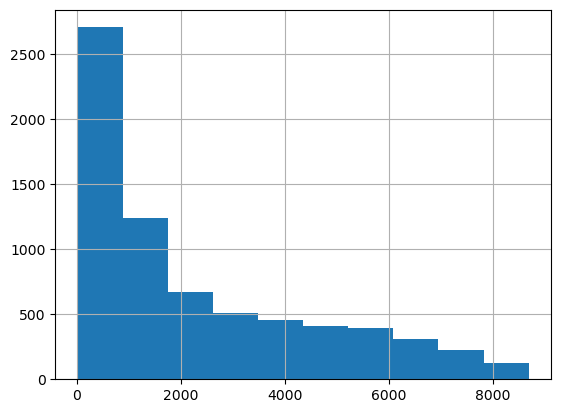

In [66]:
df['TotalCharges'].hist()
plt.show()

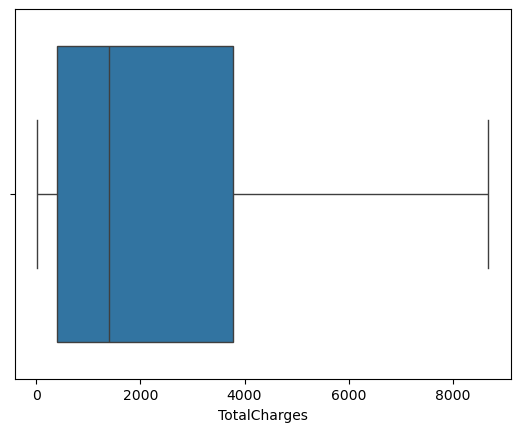

In [68]:
sns.boxplot(x=df['TotalCharges'])
plt.show()

## Observation

The TotalCharges distribution is positively skewed, with most customers having lower total charges and fewer customers having very high total charges.

Outlier analysis using a boxplot did not reveal any significant outliers. Therefore, no outlier treatment was required.

# Step 12: Feature Engineering

Prepare the dataset for ANN training.

## Remove Customer ID

CustomerID is a unique identifier and does not contribute to churn prediction.

In [73]:
df.drop('customerID', axis=1, inplace=True)

## Verify Dataset

In [76]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encode Target Variable

Convert Churn from categorical values into numerical values.

No  -> 0
Yes -> 1

In [79]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

## Verify Churn Encoding

In [82]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Encode Categorical Features

Convert categorical variables into numerical features using One-Hot Encoding.

In [87]:
df = pd.get_dummies(df, drop_first=True)

In [89]:
df = df.astype(int)

## Verify Dataset After Encoding

In [92]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## Check Dataset Shape

Observe how the number of columns changes after encoding.

In [94]:
print(df.shape)

(7043, 31)


## Observation

All categorical features have been converted into numerical features.

The dataset is now suitable for ANN model training.

# Step 13: Feature Selection

Separate input features and target variable.

In [98]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## Verify Feature Matrix and Target Variable

In [101]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


# Step 14: Train-Test Split

Split the dataset into training and testing datasets.

Training Data = 80%
Testing Data = 20%

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Verify Split

In [107]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


# Step 15: Handle Imbalanced Data using SMOTE

The target variable is imbalanced.

SMOTE creates synthetic samples for the minority class to balance the training data.

In [110]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [112]:
print(y_train.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


# Step 16: Feature Scaling

Scale numerical features so that all features contribute equally to ANN training.

ANN models perform better when input values are standardized.

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

## Fit and Transform Training Data

Learn scaling parameters from training data and apply scaling.

In [118]:
X_train = scaler.fit_transform(X_train)

## Transform Testing Data

Apply the same scaling parameters learned from training data.

In [121]:
X_test = scaler.transform(X_test)

## Verify Scaled Data

In [124]:
print(X_train[:5])

[[-0.39596907  0.29010391 -0.65002228 -0.17517397  1.1489418  -0.7837567
  -0.51963591 -2.90499511  3.38905167 -0.7946411  -1.02967421 -0.43888899
  -0.43888899 -0.51156418 -0.43888899 -0.61561122 -0.43888899  1.61558588
  -0.43888899 -0.51644716 -0.43888899  1.33511086 -0.43888899  1.32086902
  -0.41894906 -0.44552697 -1.21591246 -0.42530513  1.3697821  -0.46678715]
 [-0.39596907 -0.54289013  0.2560676  -0.42493895  1.1489418   1.27590615
   1.92442435  0.34423466 -0.29506779 -0.7946411   0.97118098 -0.43888899
  -0.43888899  1.95478893 -0.43888899 -0.61561122 -0.43888899 -0.6189705
  -0.43888899 -0.51644716 -0.43888899 -0.74900147 -0.43888899 -0.75707734
  -0.41894906 -0.44552697 -1.21591246 -0.42530513 -0.73004312  2.14230403]
 [-0.39596907 -0.62618954 -0.96366877 -0.67969924  1.1489418   1.27590615
   1.92442435 -2.90499511  3.38905167 -0.7946411  -1.02967421 -0.43888899
  -0.43888899  1.95478893 -0.43888899  1.62440183 -0.43888899 -0.6189705
  -0.43888899  1.9363065  -0.43888899 -

# Step 17: Build Artificial Neural Network (ANN)

Create a Sequential Neural Network for Customer Churn Prediction.

In [127]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [128]:
model = Sequential()

## Add Input Layer and First Hidden Layer


In [172]:
model.add(Dense(32, activation='relu', input_shape=(30,)))

C:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Add Second Hidden Layer

In [175]:
model.add(Dense(units=16, activation='relu'))

## Add Output Layer

This is a binary classification problem, so one neuron with sigmoid activation is used.

In [178]:
model.add(Dense(units=1, activation='sigmoid'))

## Display Model Summary

In [181]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,534 (9.90 KB)

 Trainable params: 1,250 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)

# Step 18: Compile ANN Model

Configure optimizer, loss function and evaluation metric.

In [184]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Configuration

Optimizer : Adam

Loss Function : Binary Crossentropy

Metric : Accuracy

# Step 19: Train ANN Model

Train the Artificial Neural Network using the training dataset.

In [187]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7881 - loss: 0.5786 - val_accuracy: 0.8859 - val_loss: 0.3210
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8235 - loss: 0.4103 - val_accuracy: 0.8973 - val_loss: 0.2644
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8286 - loss: 0.3876 - val_accuracy: 0.8992 - val_loss: 0.2737
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8288 - loss: 0.3814 - val_accuracy: 0.9300 - val_loss: 0.2110
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8295 - loss: 0.3777 - val_accuracy: 0.9076 - val_loss: 0.2658
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8325 - loss: 0.3749 - val_accuracy: 0.9372 - val_loss: 0.1949
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8342 - loss: 0.3728 - val_accuracy: 0.8919 - val_loss: 0.2789
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8362 - loss: 0.3718 - val_accu

# Step 19: Evaluate ANN Model

Evaluate model performance on unseen test data.

In [190]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7644 - loss: 0.4816 
Loss: 0.4816310703754425
Accuracy: 0.7643718719482422


# Step 19: Model Predictions

Predict customer churn using the testing dataset.

In [193]:
y_pred = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


## Convert Probabilities into Class Labels

Convert predicted probabilities into binary values.

If probability > 0.5 → Churn (1)

Else → No Churn (0)

In [196]:
y_pred = (y_pred > 0.5)

In [198]:
print(y_pred[:10])

[[False]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]]


# Step 20: Confusion Matrix

In [201]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[845 190]
 [142 232]]


## Visualize Confusion Matrix

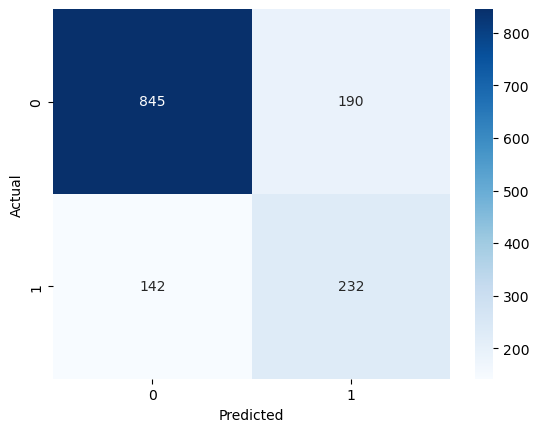

In [204]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 21: Classification Report

Evaluate Precision, Recall and F1 Score.

In [207]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



 Project Conclusion

## Objective

The objective of this project was to predict customer churn using an Artificial Neural Network (ANN).

## Challenges Faced

1. Imbalanced target variable.
2. Initial ANN predicted only the majority class.

## Improvements Applied

- Stratified Train-Test Split
- SMOTE for class balancing
- StandardScaler for feature scaling
- ANN with ReLU and Sigmoid activation functions

## Final Results

Accuracy: 76.44%

Class 1 (Churn):
- Precision: 0.55
- Recall: 0.62
- F1 Score: 0.58

## Conclusion

The ANN model successfully identified customer churn patterns. After applying SMOTE and proper preprocessing, the model improved significantly and was able to predict both churn and non-churn customers effectively.